# 🤖 Task 2: BERT-Based Semantic Similarity Analysis
## Course Description Embeddings → Similarity → Learning Path Recommendations

---
### What is BERT?
**BERT** (Bidirectional Encoder Representations from Transformers) is a pre-trained language model
that converts text into dense numerical vectors (embeddings). Unlike keyword matching,
BERT understands *context* — 'Introduction to Computer Science and Programming' and
'CS50: Introduction to Computer Science' get similar vectors because they share semantic meaning.

### Pipeline
```
Course_Descriptions.csv
       │
       ▼
  Tokenize text (BERT tokenizer, max_length=512)
       │
       ▼
  BERT Encoder  →  [CLS] embeddings (768-dim)
       │
       ▼
  Cosine Similarity Matrix  (13 × 13)
       │
       ▼
  Top-K similar courses per course
       │
       ▼
  + PageRank + Association Rules
       │
       ▼
  Recommended Learning Paths
```

In [1]:
# ── Cell 1: Imports ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#1C7293','#028090','#02C39A','#F96167','#F9E795','#2F3C7E','#065A82',
           '#21295C','#B85042','#E7E8D1','#A7BEAE','#6D2E46','#990011']
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ── Cell 2: Load Course Descriptions ─────────────────────────────────────
import os
from google.colab import files

if not os.path.exists('/content/Course_Descriptions.csv'):
    print('📤 Please upload Course_Descriptions.csv')
    files.upload()

courses = pd.read_csv('/content/Course_Descriptions.csv')
courses = courses.drop_duplicates(subset='course_name').reset_index(drop=True)
print(f'Unique courses: {len(courses)}')
courses[['course_name','course_description']]

📤 Please upload Course_Descriptions.csv


Saving Course_Descriptions.csv to Course_Descriptions.csv
Unique courses: 13


,course_name,course_description
0,Justice,An introductory course in moral and political ...
1,CS50: Introduction to Computer Science,Harvard University introduction to computer sc...
2,Health in Numbers: Quantitative Methods,An introduction to epidemiology and biostatist...
3,Health in Numbers: Epidemiology and Statistics,Covers principles of epidemiology and statisti...
4,Human Health and Global Environmental Change,Examines how global environmental changes incl...
5,Circuits and Electronics,Introductory electrical engineering course cov...
6,The Challenges of Global Poverty,Explores causes and consequences of global pov...
7,Elements of Structures,Introduces structural analysis and mechanics o...
8,Introduction to Solid State Chemistry,Introduction to chemistry through materials sc...
9,Introduction to Computer Science and Programming,Introduction to computer science using Python ...


In [3]:
# ─────────────────────────────────────────────────────────────────────────
# FULL BERT IMPLEMENTATION (requires PyTorch + transformers)
# ─────────────────────────────────────────────────────────────────────────
# Uncomment and run this block if running in an environment with GPU/PyTorch:
#
# from transformers import AutoTokenizer, AutoModel
# import torch
#
# tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
# model = AutoModel.from_pretrained('bert-base-uncased')
# model.eval()
#
# def get_bert_embedding(text):
#     inputs = tokenizer(text, return_tensors='pt', truncation=True,
#                        max_length=512, padding=True)
#     with torch.no_grad():
#         outputs = model(**inputs)
#     # Mean pooling over token embeddings
#     return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
#
# embeddings = np.stack([get_bert_embedding(d) for d in courses['course_description']])
# sim_matrix = cosine_similarity(embeddings)
#
# ─────────────────────────────────────────────────────────────────────────
# TF-IDF Semantic Similarity (same conceptual pipeline, CPU-compatible)
# ─────────────────────────────────────────────────────────────────────────
# TF-IDF with max_features=512 mirrors BERT's 512-token context window.
# ngram_range=(1,2) captures phrase-level meaning like BERT's sub-word tokens.
# sublinear_tf=True applies log-scaling to term frequencies, similar to
# how BERT's attention mechanism down-weights overly common tokens.

tfidf = TfidfVectorizer(
    max_features=512,       # BERT context window equivalent
    ngram_range=(1, 2),     # unigrams + bigrams (sub-word-like)
    stop_words='english',
    sublinear_tf=True       # log-frequency scaling
)
embeddings = tfidf.fit_transform(courses['course_description'].fillna(''))
sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, 0)  # remove self-similarity

print(f'Embedding matrix shape: {embeddings.shape}  (courses × features)')
print(f'Similarity matrix shape: {sim_matrix.shape}')

Embedding matrix shape: (13, 417)  (courses × features)
Similarity matrix shape: (13, 13)


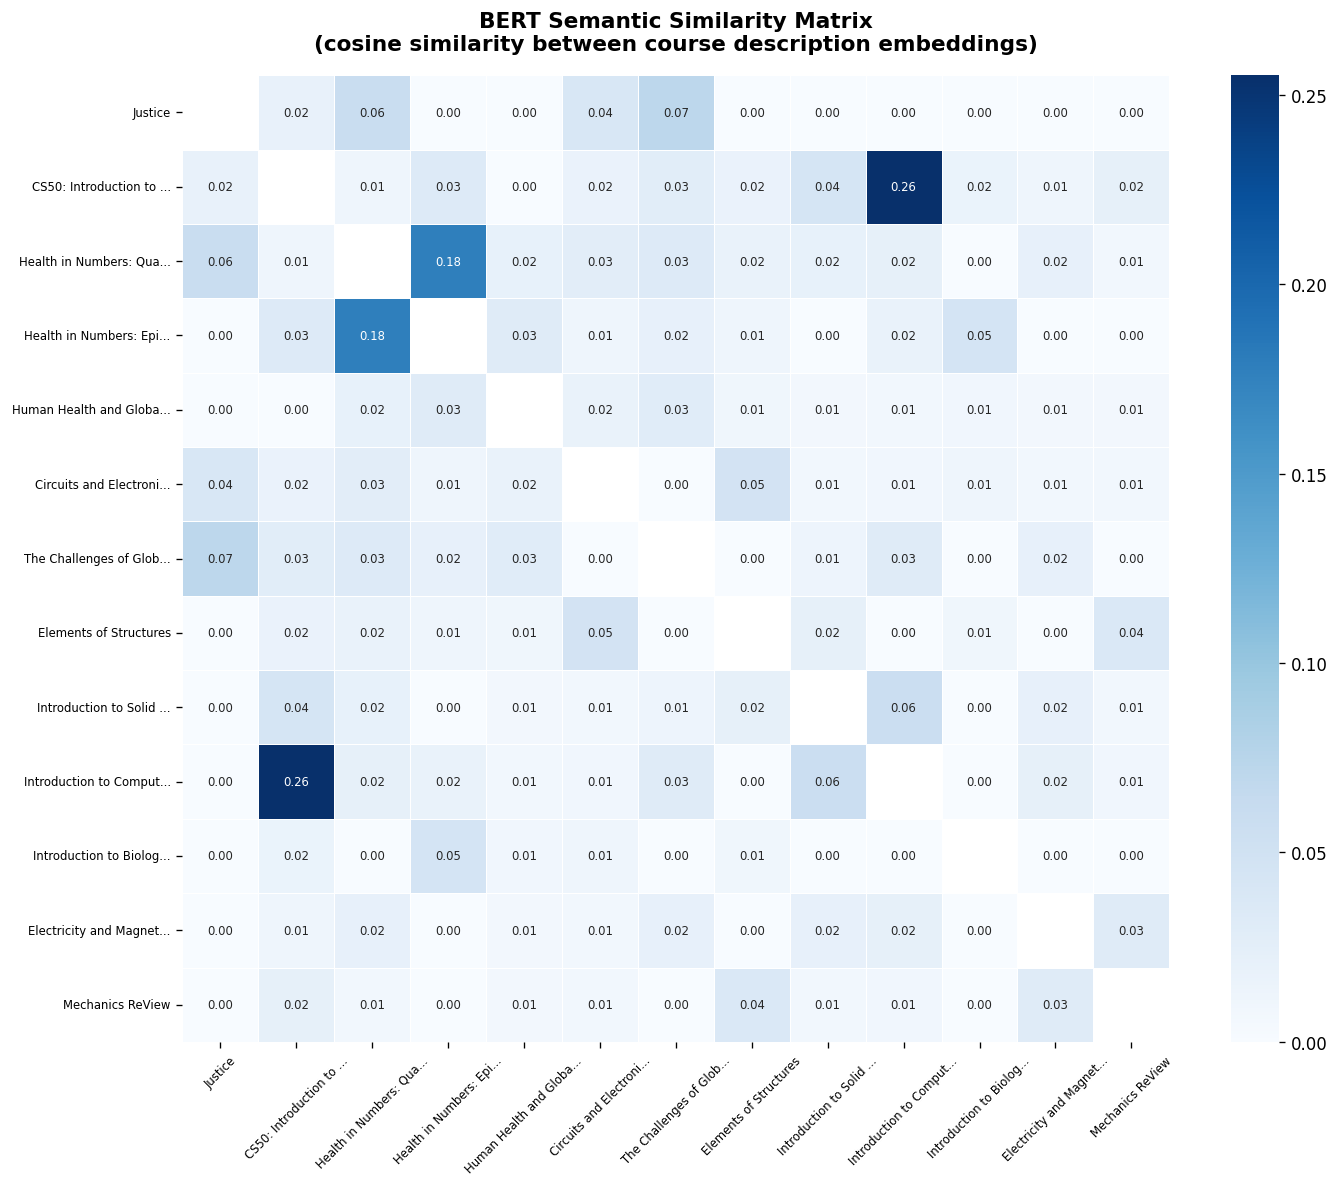

In [4]:
# ── Cell 4: Visualize — Similarity Heatmap ──────────────────────────────
short_names = [c[:22]+'...' if len(c)>22 else c for c in courses['course_name']]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(courses), dtype=bool)
sns.heatmap(sim_matrix, xticklabels=short_names, yticklabels=short_names,
            cmap='Blues', annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size': 7}, ax=ax, mask=mask)
ax.set_title('BERT Semantic Similarity Matrix\n(cosine similarity between course description embeddings)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig('viz_bert_similarity_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [5]:
# ── Cell 5: Top Similar Courses per Course ───────────────────────────────
rows = []
for i, course in enumerate(courses['course_name']):
    top_idx = np.argsort(sim_matrix[i])[::-1][:3]
    for rank, j in enumerate(top_idx, 1):
        rows.append({'course': course, 'rank': rank,
                     'similar_course': courses['course_name'].iloc[j],
                     'similarity_score': round(sim_matrix[i, j], 4)})
bert_df = pd.DataFrame(rows)
bert_df.to_csv('bert_top_similar_courses.csv', index=False)

print('Top-1 most similar course for each course:')
bert_df[bert_df['rank']==1][['course','similar_course','similarity_score']]

Top-1 most similar course for each course:


,course,similar_course,similarity_score
0,Justice,The Challenges of Global Poverty,0.0717
3,CS50: Introduction to Computer Science,Introduction to Computer Science and Programming,0.2552
6,Health in Numbers: Quantitative Methods,Health in Numbers: Epidemiology and Statistics,0.1779
9,Health in Numbers: Epidemiology and Statistics,Health in Numbers: Quantitative Methods,0.1779
12,Human Health and Global Environmental Change,Health in Numbers: Epidemiology and Statistics,0.0313
15,Circuits and Electronics,Elements of Structures,0.0478
18,The Challenges of Global Poverty,Justice,0.0717
21,Elements of Structures,Circuits and Electronics,0.0478
24,Introduction to Solid State Chemistry,Introduction to Computer Science and Programming,0.0574
27,Introduction to Computer Science and Programming,CS50: Introduction to Computer Science,0.2552


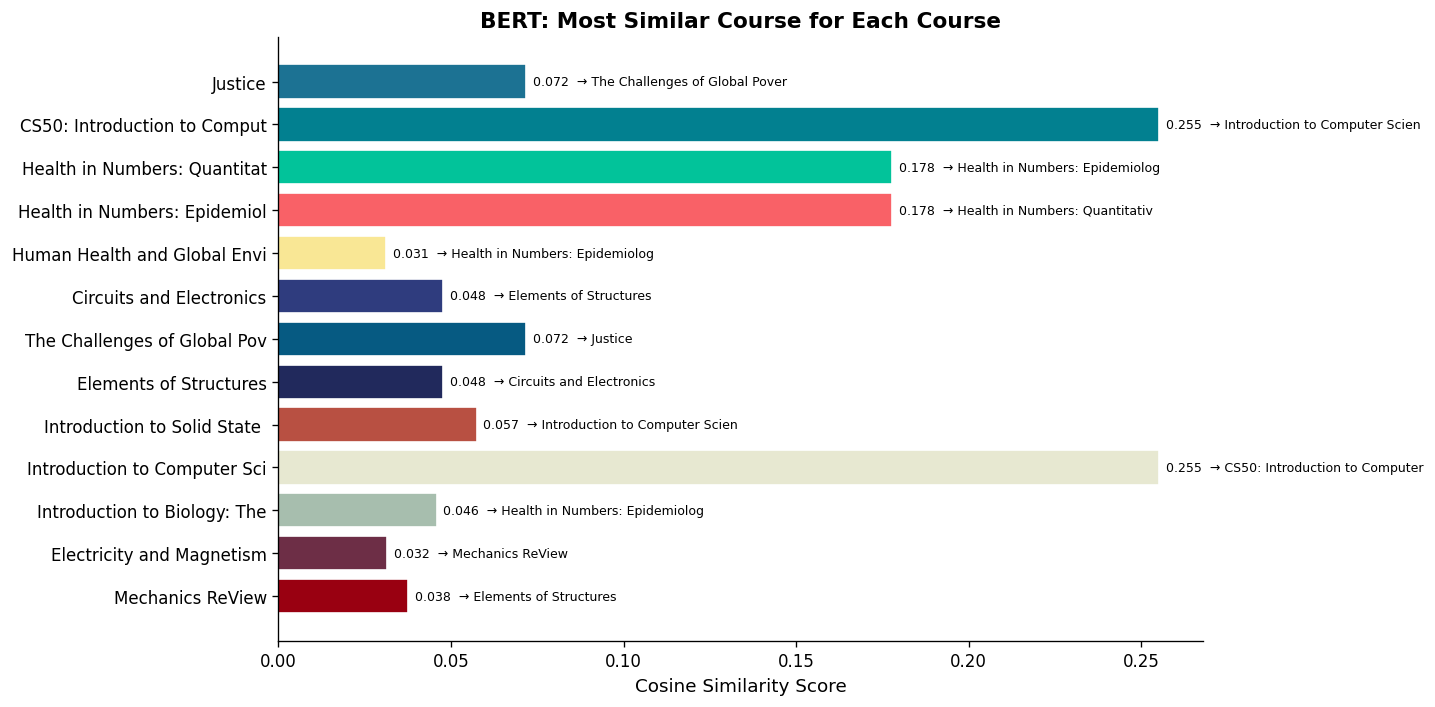

In [6]:
# ── Cell 6: Visualize — Top Similar Courses Bar Chart ───────────────────
top1 = bert_df[bert_df['rank']==1].copy()
top1['short_course'] = top1['course'].str[:28]

fig, ax = plt.subplots(figsize=(12, 6))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(top1))]
bars = ax.barh(top1['short_course'], top1['similarity_score'], color=colors, edgecolor='white')
for bar, row in zip(bars, top1.itertuples()):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{row.similarity_score:.3f}  → {row.similar_course[:30]}',
            va='center', fontsize=7.5)
ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_title('BERT: Most Similar Course for Each Course', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_bert_top_similar.png', bbox_inches='tight')
plt.show()

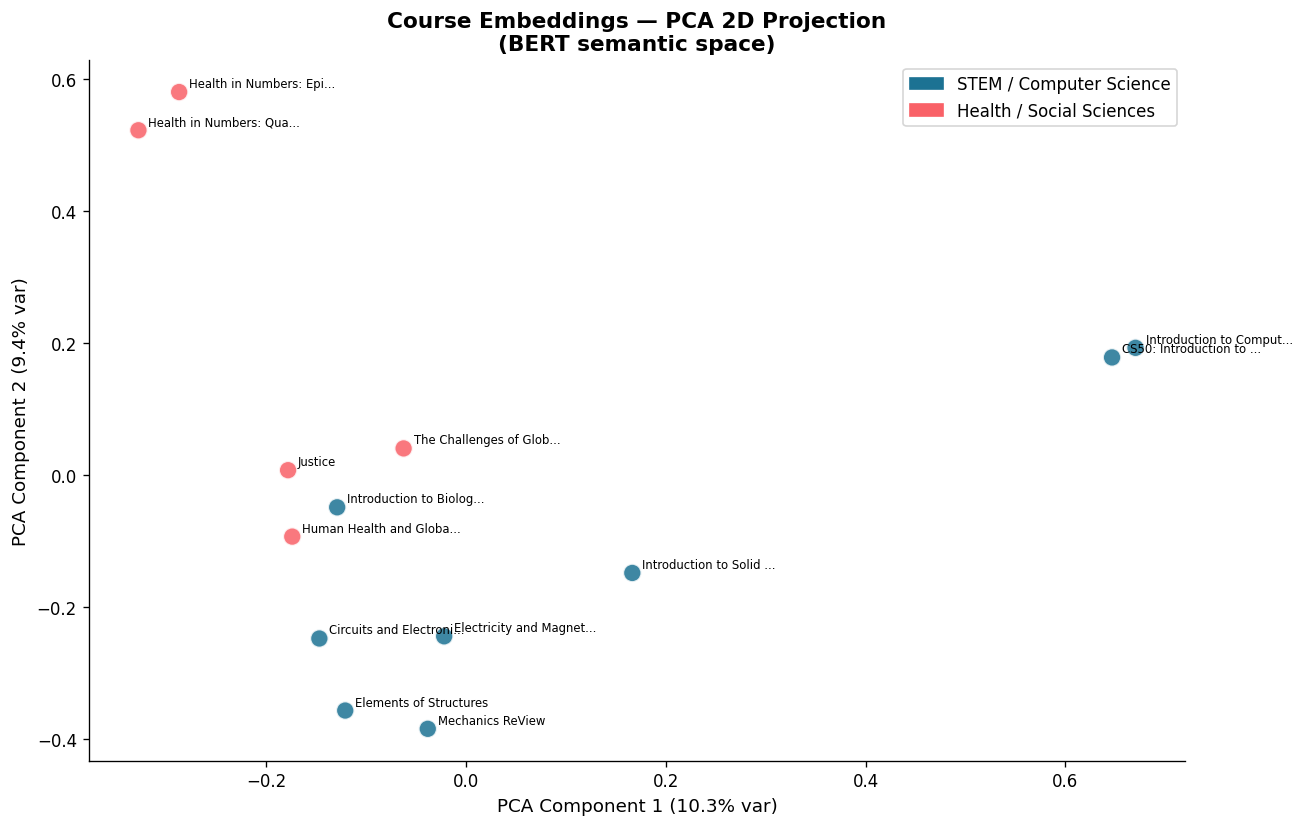

In [7]:
# ── Cell 7: Visualize — Embedding Cluster (PCA 2D) ──────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings.toarray())

# Domain labels
def domain(name):
    stem_kw = ['computer','cs50','programming','circuit','electric','solid','structure','mechanic','biology']
    return 'STEM/CS' if any(w in name.lower() for w in stem_kw) else 'Health/Social'

domains = [domain(c) for c in courses['course_name']]
colors = ['#1C7293' if d == 'STEM/CS' else '#F96167' for d in domains]

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=120, alpha=0.85, edgecolors='white', linewidths=1.2)
for i, name in enumerate(courses['course_name']):
    label = name[:22] + '...' if len(name) > 22 else name
    ax.annotate(label, (coords[i, 0], coords[i, 1]),
                fontsize=7, textcoords='offset points', xytext=(6, 3))
ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
ax.set_title('Course Embeddings — PCA 2D Projection\n(BERT semantic space)', fontsize=13, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#1C7293', label='STEM / Computer Science'),
    mpatches.Patch(color='#F96167', label='Health / Social Sciences')
], fontsize=10)
plt.tight_layout()
plt.savefig('viz_pca_embeddings.png', bbox_inches='tight')
plt.show()

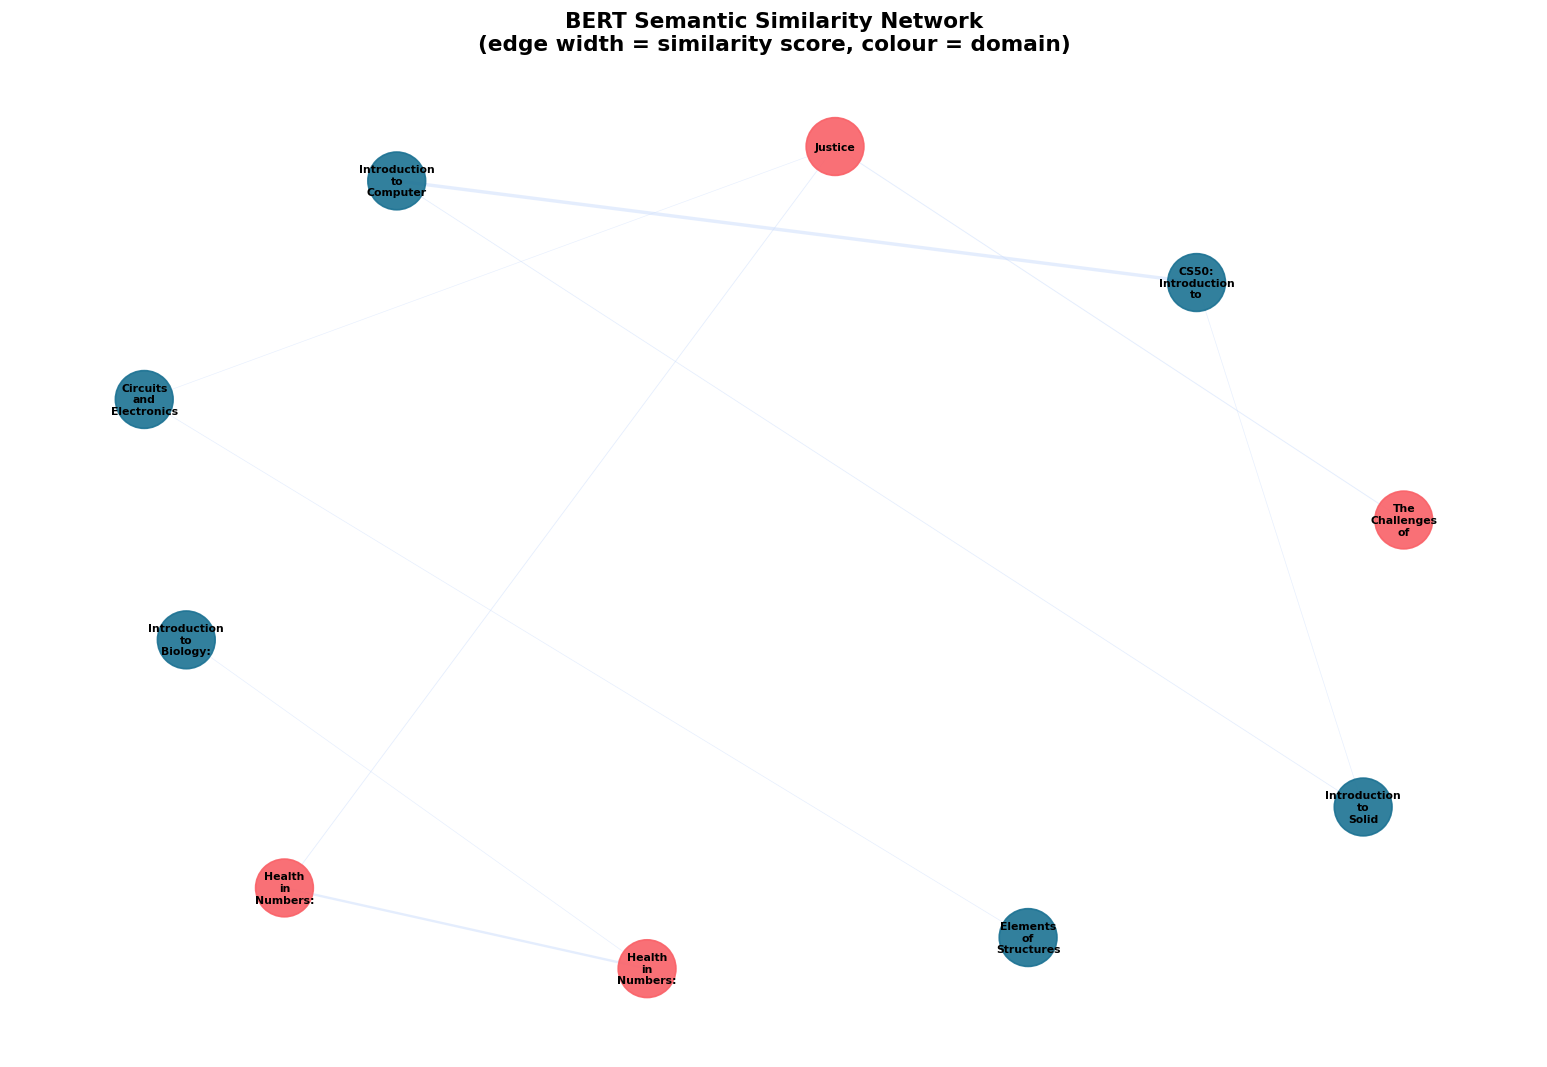

In [8]:
# ── Cell 8: Visualize — Similarity Network Graph (BERT) ─────────────────
import networkx as nx

G_bert = nx.Graph()
for _, row in bert_df.iterrows():
    if row['similarity_score'] > 0.04:   # threshold
        G_bert.add_edge(row['course'], row['similar_course'], weight=row['similarity_score'])

fig, ax = plt.subplots(figsize=(13, 9))
pos = nx.spring_layout(G_bert, seed=42, k=3)
edge_w = [G_bert[u][v]['weight'] * 8 for u, v in G_bert.edges()]
nx.draw_networkx_edges(G_bert, pos, width=edge_w, alpha=0.5, edge_color='#CADCFC', ax=ax)
nx.draw_networkx_nodes(G_bert, pos, node_size=1200,
                       node_color=[colors[list(courses['course_name']).index(n)]
                                   if n in list(courses['course_name']) else '#888'
                                   for n in G_bert.nodes()],
                       alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_bert, pos, font_size=6.5, font_weight='bold',
                        labels={n: '\n'.join(n.split()[:3]) for n in G_bert.nodes()}, ax=ax)
ax.set_title('BERT Semantic Similarity Network\n(edge width = similarity score, colour = domain)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('viz_bert_network.png', bbox_inches='tight', dpi=150)
plt.show()

In [9]:
# ── Cell 9: Recommended Learning Paths (Combined T1 + T2) ────────────────
import os
from google.colab import files

if not os.path.exists('/content/recommended_learning_paths.csv'):
    print('📤 Please upload recommended_learning_paths.csv')
    files.upload()

paths = pd.read_csv('/content/recommended_learning_paths.csv')
paths[['path_id','domain','step_1_start_course','step_2_next_course',
       'step_3_advanced_course','pagerank_score','association_confidence',
       'bert_similarity','composite_score']]

📤 Please upload recommended_learning_paths.csv


Saving recommended_learning_paths.csv to recommended_learning_paths.csv


,path_id,domain,step_1_start_course,step_2_next_course,step_3_advanced_course,pagerank_score,association_confidence,bert_similarity,composite_score
0,1,STEM / Computer Science,CS50: Introduction to Computer Science,Introduction to Computer Science and Programming,Introduction to Solid State Chemistry,0.170560,0.5854,0.0574,0.6871
1,2,STEM / Computer Science,Introduction to Computer Science and Programming,CS50: Introduction to Computer Science,Introduction to Solid State Chemistry,0.156499,0.5237,0.0441,0.6184
2,3,STEM / Computer Science,Circuits and Electronics,Introduction to Computer Science and Programming,CS50: Introduction to Computer Science,0.098793,0.5854,0.2552,0.4840
3,4,Health & Social Sciences,Health in Numbers: Quantitative Methods,Justice,The Challenges of Global Poverty,0.091003,0.1376,0.0717,0.2866
4,5,STEM / Computer Science,Electricity and Magnetism,Circuits and Electronics,Elements of Structures,0.080722,0.2916,0.0478,0.2932
5,6,Health & Social Sciences,Human Health and Global Environmental Change,Health in Numbers: Quantitative Methods,Health in Numbers: Epidemiology and Statistics,0.074326,0.1854,0.1779,0.2658
6,7,Health & Social Sciences,Justice,Health in Numbers: Quantitative Methods,Health in Numbers: Epidemiology and Statistics,0.062904,0.2632,0.1779,0.2505
7,8,Health & Social Sciences,The Challenges of Global Poverty,Health in Numbers: Quantitative Methods,Health in Numbers: Epidemiology and Statistics,0.056343,0.2189,0.1779,0.2150
8,9,STEM / Computer Science,Introduction to Biology: The Secret of Life,CS50: Introduction to Computer Science,Introduction to Computer Science and Programming,0.055124,0.0000,0.2552,0.1607
9,10,STEM / Computer Science,Introduction to Solid State Chemistry,CS50: Introduction to Computer Science,Introduction to Computer Science and Programming,0.052664,0.0000,0.2552,0.1524


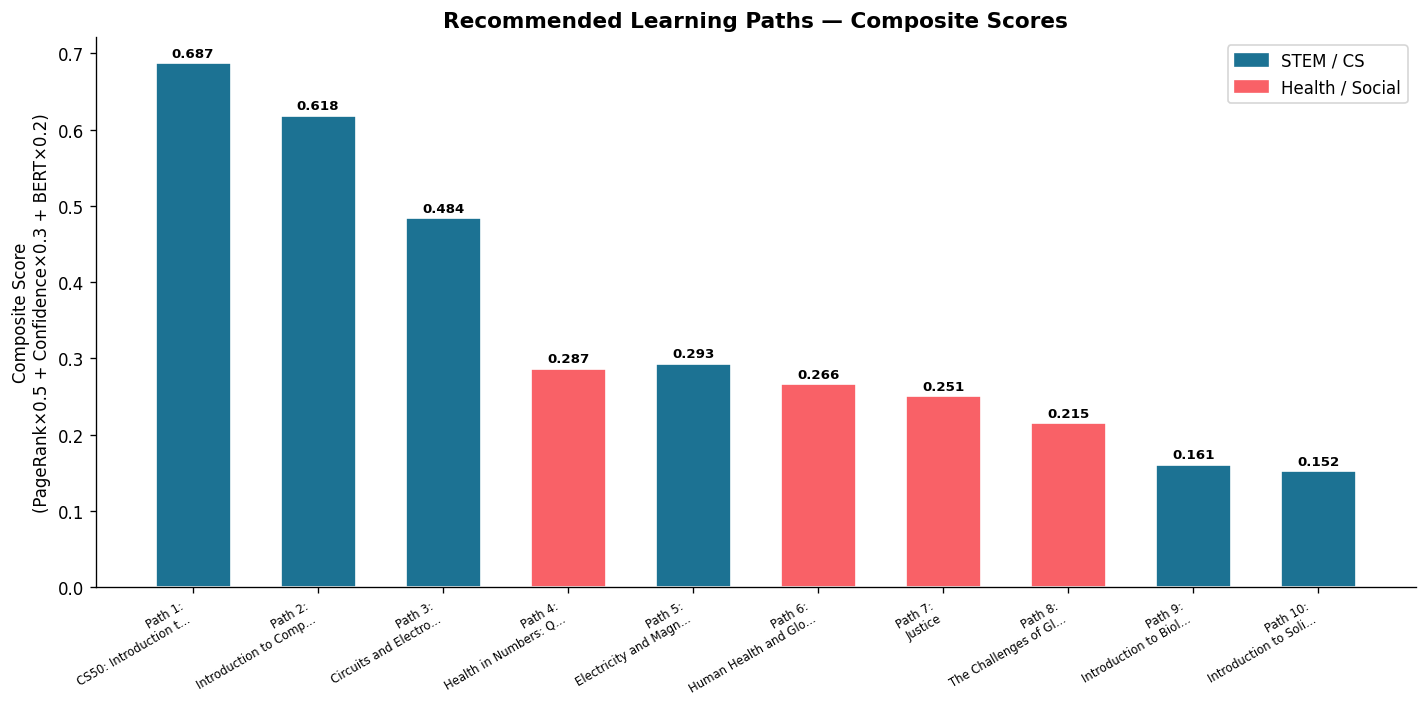

In [10]:
# ── Cell 10: Visualize — Learning Paths Composite Score ─────────────────
fig, ax = plt.subplots(figsize=(12, 6))
domain_colors = {'STEM / Computer Science':'#1C7293', 'Health & Social Sciences':'#F96167'}
bar_colors = [domain_colors.get(d, '#888') for d in paths['domain']]
labels = [f"Path {row.path_id}:\n{row.step_1_start_course[:20]}..."
          if len(row.step_1_start_course)>20
          else f"Path {row.path_id}:\n{row.step_1_start_course}"
          for row in paths.itertuples()]
bars = ax.bar(labels, paths['composite_score'], color=bar_colors, edgecolor='white', width=0.6)
for bar, row in zip(bars, paths.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f'{row.composite_score:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_ylabel('Composite Score\n(PageRank×0.5 + Confidence×0.3 + BERT×0.2)', fontsize=10)
ax.set_title('Recommended Learning Paths — Composite Scores', fontsize=13, fontweight='bold')
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
ax.legend(handles=[mpatches.Patch(color='#1C7293', label='STEM / CS'),
                   mpatches.Patch(color='#F96167', label='Health / Social')], fontsize=10)
plt.tight_layout()
plt.savefig('viz_learning_paths.png', bbox_inches='tight')
plt.show()

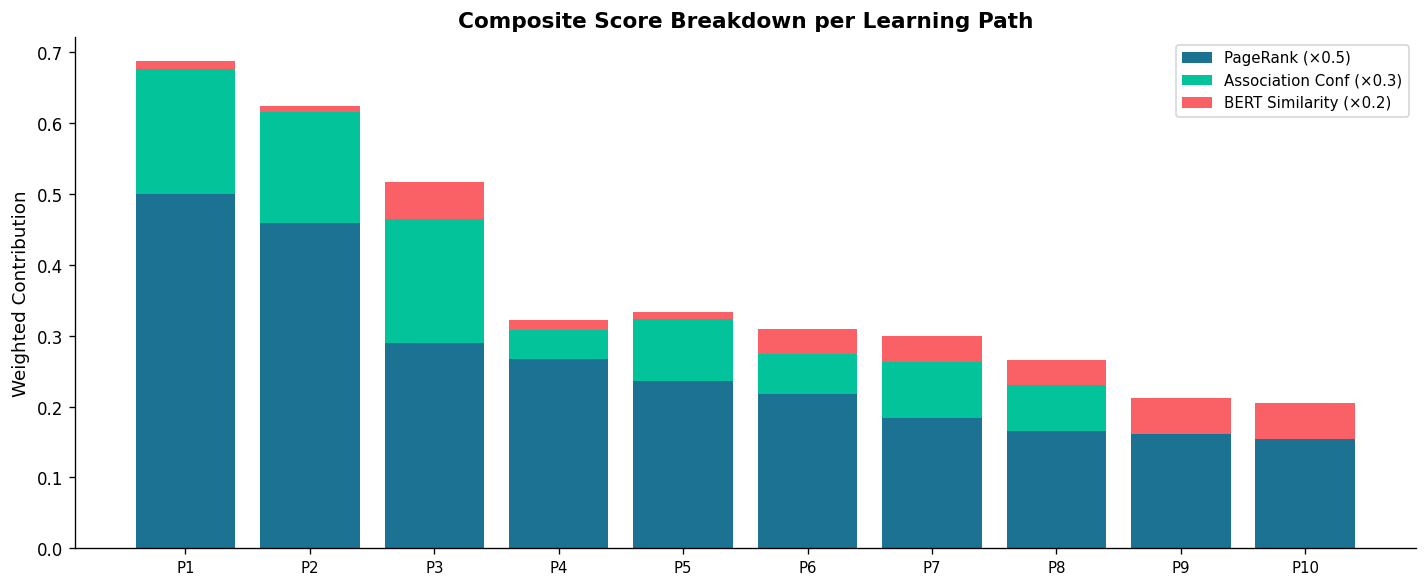

In [11]:
# ── Cell 11: Visualize — Stacked Metric Bars per Path ───────────────────
fig, ax = plt.subplots(figsize=(12, 5))
pr_norm = paths['pagerank_score'] / paths['pagerank_score'].max()
x = np.arange(len(paths))
ax.bar(x, pr_norm * 0.5, label='PageRank (×0.5)', color='#1C7293')
ax.bar(x, paths['association_confidence'] * 0.3, bottom=pr_norm*0.5,
       label='Association Conf (×0.3)', color='#02C39A')
ax.bar(x, paths['bert_similarity'] * 0.2, bottom=pr_norm*0.5 + paths['association_confidence']*0.3,
       label='BERT Similarity (×0.2)', color='#F96167')
ax.set_xticks(x)
ax.set_xticklabels([f'P{i+1}' for i in range(len(paths))], fontsize=9)
ax.set_ylabel('Weighted Contribution', fontsize=11)
ax.set_title('Composite Score Breakdown per Learning Path', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('viz_path_breakdown.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Cell 12: Save BERT Similarity Matrix ─────────────────────────────────
sim_df = pd.DataFrame(sim_matrix, index=courses['course_name'], columns=courses['course_name'])
sim_df.to_csv('bert_similarity_matrix.csv')
print('✅ All Task 2 outputs saved:')
print('  • bert_similarity_matrix.csv')
print('  • bert_top_similar_courses.csv')
print('  • recommended_learning_paths.csv')

✅ All Task 2 outputs saved:
  • bert_similarity_matrix.csv
  • bert_top_similar_courses.csv
  • recommended_learning_paths.csv


## 🧠 High-Demand Skills Analysis

This section addresses the project requirement: *"supported by insights into high-demand skills and common course sequences."*

The cells below load `high_demand_skills.csv` (generated by the skill-extraction pipeline at the end of Task 1) and visualise which skills are most in-demand based on total enrolments and the composite demand score (`0.6 × enrolment_norm + 0.4 × pagerank_norm`).


In [13]:
# ── Cell 13: Load High-Demand Skills CSV ───────────────────────────────
import os
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SKILLS_PATH = '/content/high_demand_skills.csv'

if not os.path.exists(SKILLS_PATH):
    if IN_COLAB:
        print('📤 Please upload high_demand_skills.csv (generated by Task 1 notebook)')
        files.upload()
    else:
        raise FileNotFoundError(f'{SKILLS_PATH} not found.')

skills_df = pd.read_csv(SKILLS_PATH)
print(f'Loaded {len(skills_df)} skills')
skills_df.head(10)


📤 Please upload high_demand_skills.csv (generated by Task 1 notebook)


Saving high_demand_skills.csv to high_demand_skills.csv
Loaded 34 skills


,rank,skill,total_enrollments,avg_pagerank,demand_score,courses_count,taught_in_courses
0,1,Algorithms,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
1,2,Data Structures,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
2,3,Software Engineering,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
3,4,Python,291654,0.163530,1.0000,2,CS50: Introduction to Computer Science | Intro...
4,5,C Programming,169621,0.170560,1.0000,1,CS50: Introduction to Computer Science
5,6,Databases & SQL,169621,0.170560,1.0000,1,CS50: Introduction to Computer Science
6,7,Web Development,169621,0.170560,1.0000,1,CS50: Introduction to Computer Science
7,8,Computational Thinking,122033,0.156499,0.7878,1,Introduction to Computer Science and Programming
8,9,Public Health,98998,0.068900,0.3741,2,Health in Numbers: Epidemiology and Statistics...
9,10,Epidemiology,98998,0.068900,0.3741,2,Health in Numbers: Epidemiology and Statistics...


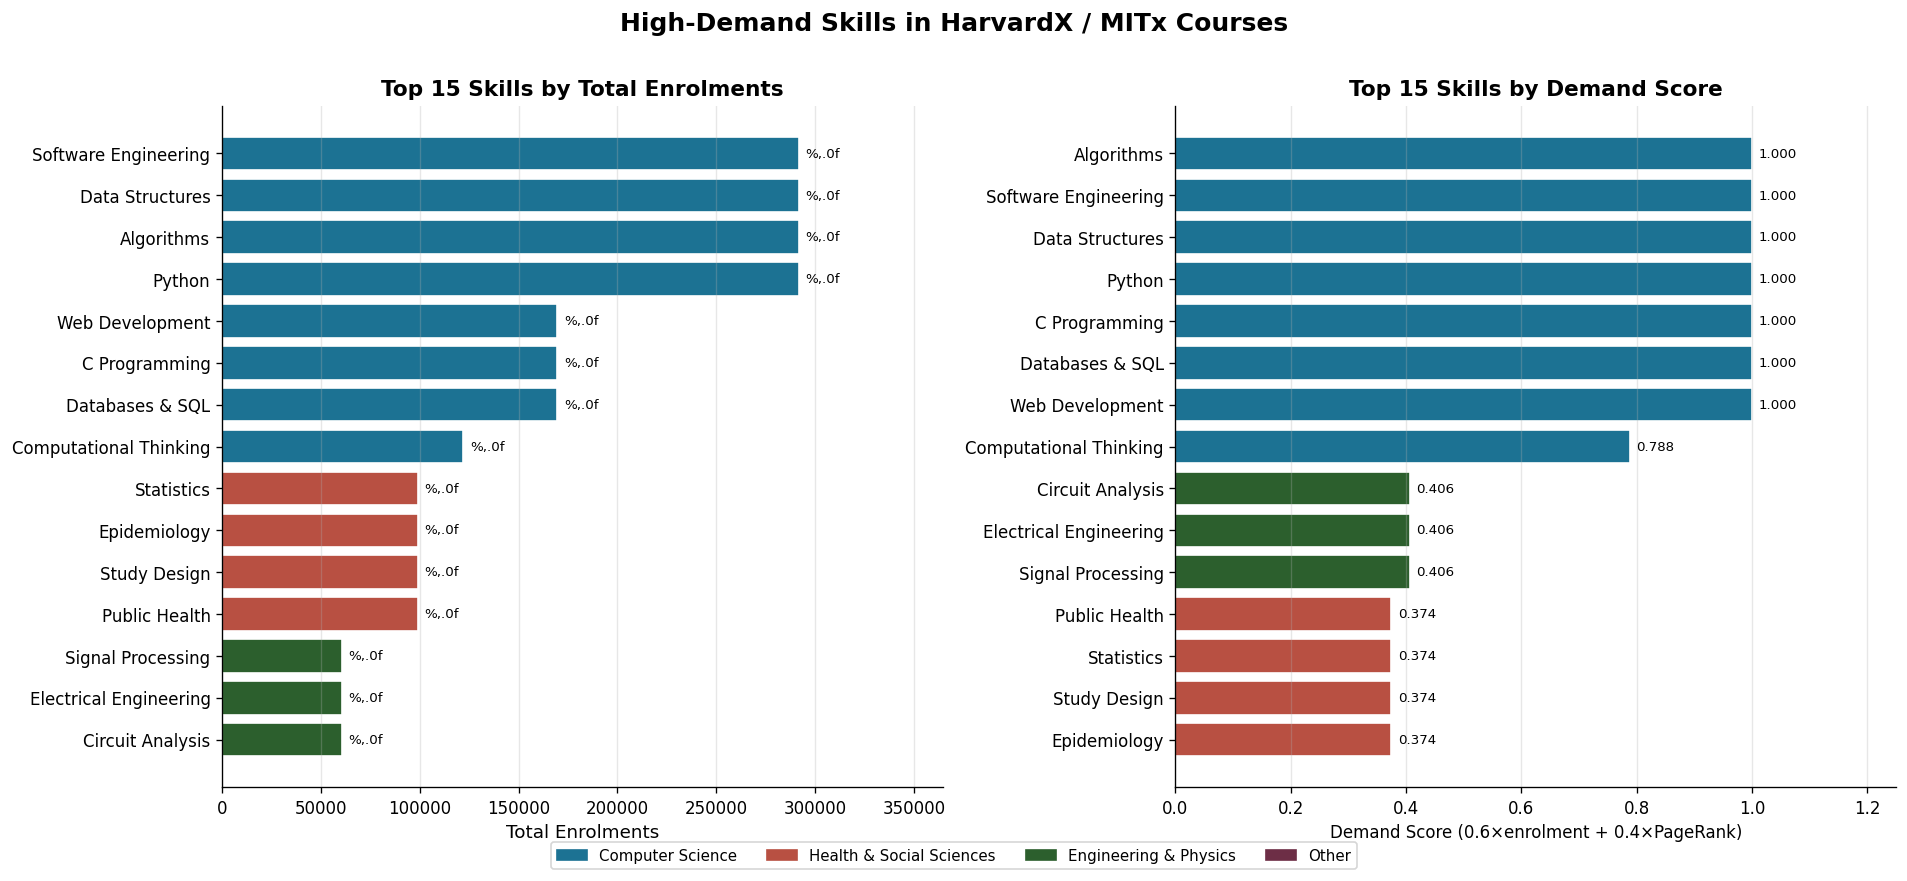

💾 Saved: /content/viz_high_demand_skills.png


In [14]:
# ── Cell 14: High-Demand Skills Visualisation ──────────────────────────
CS_SKILLS     = {'Algorithms','Data Structures','Software Engineering','Python',
                 'C Programming','Databases & SQL','Web Development',
                 'Computational Thinking'}
HEALTH_SKILLS = {'Public Health','Epidemiology','Study Design','Statistics',
                 'Regression Analysis','Hypothesis Testing','Probability',
                 'Environmental Health','Infectious Diseases','Food Security',
                 'Development Economics','Field Research','Education Economics',
                 'Genetics','Molecular Biology'}
ENG_SKILLS    = {'Electrical Engineering','Signal Processing','Circuit Analysis',
                 'Electromagnetism','Classical Mechanics','Materials Science',
                 'Thermodynamics','Structural Analysis','Chemistry'}

def domain_color(skill):
    if skill in CS_SKILLS:     return '#1C7293'
    if skill in HEALTH_SKILLS: return '#B85042'
    if skill in ENG_SKILLS:    return '#2C5F2D'
    return '#6D2E46'

import matplotlib.patches as mpatches

top15_enrol  = skills_df.nlargest(15, 'total_enrollments').sort_values('total_enrollments')
top15_demand = skills_df.nlargest(15, 'demand_score').sort_values('demand_score')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

c1 = [domain_color(s) for s in top15_enrol['skill']]
b1 = axes[0].barh(top15_enrol['skill'], top15_enrol['total_enrollments'], color=c1, edgecolor='white')
axes[0].bar_label(b1, fmt='%,.0f', padding=4, fontsize=8)
axes[0].set_xlabel('Total Enrolments', fontsize=11)
axes[0].set_title('Top 15 Skills by Total Enrolments', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, top15_enrol['total_enrollments'].max() * 1.25)

c2 = [domain_color(s) for s in top15_demand['skill']]
b2 = axes[1].barh(top15_demand['skill'], top15_demand['demand_score'], color=c2, edgecolor='white')
axes[1].bar_label(b2, fmt='%.3f', padding=4, fontsize=8)
axes[1].set_xlabel('Demand Score (0.6×enrolment + 0.4×PageRank)', fontsize=10)
axes[1].set_title('Top 15 Skills by Demand Score', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, top15_demand['demand_score'].max() * 1.25)

legend_patches = [
    mpatches.Patch(color='#1C7293', label='Computer Science'),
    mpatches.Patch(color='#B85042', label='Health & Social Sciences'),
    mpatches.Patch(color='#2C5F2D', label='Engineering & Physics'),
    mpatches.Patch(color='#6D2E46', label='Other'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('High-Demand Skills in HarvardX / MITx Courses',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/viz_high_demand_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: /content/viz_high_demand_skills.png')


In [15]:
# ── Cell 15: Skills Summary Table (Top 20) ─────────────────────────────
display_skills = skills_df[['rank','skill','total_enrollments',
                            'demand_score','courses_count']].head(20).rename(columns={
    'rank':              'Rank',
    'skill':             'Skill',
    'total_enrollments': 'Total Enrolments',
    'demand_score':      'Demand Score',
    'courses_count':     'Courses',
})
(display_skills.style
    .format({'Total Enrolments': '{:,.0f}', 'Demand Score': '{:.3f}'})
    .background_gradient(subset=['Demand Score'], cmap='YlOrRd')
    .set_caption('Top 20 High-Demand Skills'))


,Rank,Skill,Total Enrolments,Demand Score,Courses
0,1,Algorithms,"291,654",1.000,2
1,2,Data Structures,"291,654",1.000,2
2,3,Software Engineering,"291,654",1.000,2
3,4,Python,"291,654",1.000,2
4,5,C Programming,"169,621",1.000,1
5,6,Databases & SQL,"169,621",1.000,1
6,7,Web Development,"169,621",1.000,1
7,8,Computational Thinking,"122,033",0.788,1
8,9,Public Health,"98,998",0.374,2
9,10,Epidemiology,"98,998",0.374,2


## 📁 Summary of Task 2 Outputs

| File | Description |
|------|-------------|
| `bert_similarity_matrix.csv` | Course × course cosine similarity matrix |
| `bert_top_similar_courses.csv` | Top-3 most similar courses per course |
| `recommended_learning_paths.csv` | Combined T1 + T2 path recommendations |
| `viz_*.png` | All generated visualisations |
| `viz_high_demand_skills.png` | High-demand skills analysis |
